In [1]:
import os
import sys

PROJECT_NAME = 'june-2026'

try:

    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_ROOT = f'D:/Data-Science/Practice/PnT/{PROJECT_NAME}'

    print("Running in Google Colab.")

except:

    PROJECT_ROOT = rf'D:/Data-Science/Practice/PnT/{PROJECT_NAME}'

    print("Running in local environment.")

# Move to project root
os.chdir(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

Running in local environment.
Current working directory: D:\Data-Science\Practice\PnT\june-2026


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
df = sns.load_dataset("iris")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [5]:
df.shape

(150, 5)

In [6]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

In [7]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [8]:
df.nunique()

sepal_length    35
sepal_width     23
petal_length    43
petal_width     22
species          3
dtype: int64

In [9]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
df.min(numeric_only=True)

sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64

In [11]:
df.max(numeric_only=True)

sepal_length    7.9
sepal_width     4.4
petal_length    6.9
petal_width     2.5
dtype: float64

In [12]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

In [13]:
df["species"] = df["species"].astype("category")
df.dtypes

sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object

In [ ]:
numeric_cols = df.select_dtypes(np.number).columns

stat_table = pd.DataFrame()

stat_table["Mean"] = df[numeric_cols].mean()
stat_table["Q1"] = df[numeric_cols].quantile(.25)
stat_table["Q3"] = df[numeric_cols].quantile(.75)
stat_table["IQR"] = stat_table["Q3"] - stat_table["Q1"] 
stat_table["Lower_Bound"] = stat_table["Q1"] - (1.5 * stat_table["IQR"])
stat_table

,Mean,Q1,Q3,IQR,Lower_Bound
sepal_length,5.843333,5.1,6.4,1.3,3.15
sepal_width,3.057333,2.8,3.3,0.5,2.05
petal_length,3.758000,1.6,5.1,3.5,-3.65
petal_width,1.199333,0.3,1.8,1.5,-1.95


In [27]:
population_mean = df["petal_length"].mean()
sample = df["petal_length"].sample(n=30, random_state=42)
sample_mean = sample.mean()

print(population_mean, sample_mean)
print(f"Diff:", population_mean-sample_mean)

3.7580000000000005 3.8833333333333337
Diff: -0.1253333333333333


<Axes: xlabel='petal_length', ylabel='Count'>

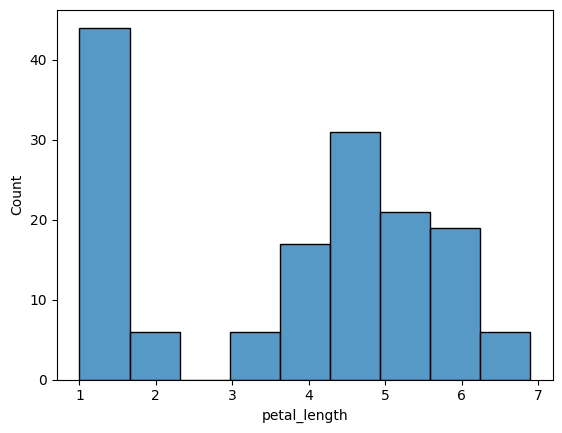

In [35]:
sns.histplot(df["petal_length"])

In [33]:
# CLI

sample_mean = []

for i in range(1000):
    sample = df["petal_length"].sample(n=30, replace=True)
    sample_mean.append(sample.mean())

sample_mean = np.array(sample_mean)
mean_of_sample_mean = sample_mean.mean()

print(population_mean, mean_of_sample_mean)
print(f"Diff:", population_mean-mean_of_sample_mean)

3.7580000000000005 3.770366666666667
Diff: -0.012366666666666415


<Axes: ylabel='Count'>

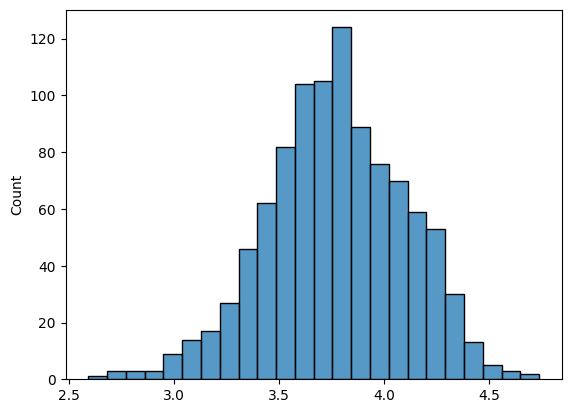

In [34]:
sns.histplot(sample_mean)

In [38]:
x = df["petal_length"]
y = df["petal_width"]

cov_matrix = x.cov(y)

print("Covariance:", cov_matrix)

Covariance: 1.2956093959731545
